In [1]:
import numpy as np
import matplotlib.pyplot as plt
import astropy.io.fits as pyfits

from lenstronomy.Data.imaging_data import ImageData
from lenstronomy.Data.psf import PSF
from lenstronomy.LightModel.light_model import LightModel
from lenstronomy.LensModel.lens_model import LensModel
from lenstronomy.LensModel.Solver.lens_equation_solver import LensEquationSolver
from lenstronomy.PointSource.point_source import PointSource
from lenstronomy.ImSim.image_model import ImageModel
import lenstronomy.Util.simulation_util as sim_util
from lenstronomy.Util import kernel_util

In [2]:
noise_sim = pyfits.getdata("..//fits//sim_noise1.image.fits")
noise_sim = noise_sim[0][0]
noise_sim = np.nan_to_num(noise_sim)

pb_sim = pyfits.getdata("..//fits//sim_noise1.pb.fits")
pb_sim = pb_sim[0][0]
pb_sim = np.nan_to_num(pb_sim)

psf_sim = pyfits.getdata("..//fits//sim_noise1.psf.fits")
psf_sim = psf_sim[0][0]
psf_sim=np.nan_to_num(psf_sim)

In [3]:
pb_cut = pb_sim[50:150, 50:150] * 0.9  # use a pb of values smaller than 1 to test the pb implementation
psf_pixel = psf_sim[150:351,150:351]

In [4]:
background_rms = 1e-4
exp_time = np.inf  #  exposure time (arbitrary units, flux per pixel is in units #photons/exp_time unit)
numPix = 100  #  cutout pixel size
deltaPix = 0.035  #  pixel size in arcsec (area per pixel = deltaPix**2)
psf_type = 'PIXEL'  # 'gaussian', 'pixel', 'NONE'
kernel_size = 201  # PSF kernel size (odd number required).

# initial input simulation
from lenstronomy.Data.imaging_data import ImageData
from lenstronomy.Data.psf import PSF
# generate the coordinate grid and image properties
kwargs_data = sim_util.data_configure_simple(numPix, deltaPix, exp_time, background_rms)
kwargs_data['ra_at_xy_0'] = -(50)*deltaPix
kwargs_data['dec_at_xy_0'] = -(50)*deltaPix
kwargs_data['antenna_primary_beam'] = pb_cut
kwargs_data['likelihood_method'] = 'interferometry_natwt'

# generate the psf variables
kernel_cut = kernel_util.cut_psf(psf_pixel, kernel_size, normalisation=False)
kwargs_psf = {'psf_type': psf_type, 'pixel_size': deltaPix, 
                    'kernel_point_source': kernel_cut, 'kernel_point_source_normalisation': False}
psf_class = PSF(**kwargs_psf)
data_class = ImageData(**kwargs_data)

kwargs_numerics = {'supersampling_convolution': False}

C:\Users\Administrator\AppData\Roaming\Python\Python38\site-packages\lenstronomy\Data\psf.py:95: UserWarning: Input PSF model has at least one negative element, which is unphysical except for a PSF of an interferometric array.
  warnings.warn(


In [5]:
point_source_model_list = ['UNLENSED']
point_source_class = PointSource(point_source_type_list=point_source_model_list)
kwargs_ps = [{'ra_image': [-0.28, -1.33, 0.87, -0.64, -0.15], 
              'dec_image': [0.41, -0.41, 1.3, 0.13, -0.55], 
              'point_amp': [47e-4, 39e-4, 43e-4, 56e-4, 49e-4]}]

In [6]:
imageModel = ImageModel(data_class, psf_class, point_source_class=point_source_class)
image_noiseless = imageModel.image(kwargs_ps=kwargs_ps)

In [9]:
# Noise image cut by sim number: 0: [50:150, 50:150], 1: [180:280, 50:150], 2: [320:420, 50:150]
# 3: [50:150, 200:300], 4: [150:250, 200:300], 5: [250:350, 200:300], 6: [350:450, 200:300]
# 7: [50:150, 350:450], 8: [170:270, 350:450], 9: [380:480, 350:450]
list_noise_cut_x0 = [50, 50, 50, 200, 200, 200, 200, 350, 350, 350]
list_noise_cut_y0 = [50, 180, 320, 50, 150, 250, 350, 50, 170, 380]
sim_image_noisy_set = np.zeros((10,100,100))

for sim in range(10):
    noise_cut_tmp = noise_sim[list_noise_cut_y0[sim]:list_noise_cut_y0[sim]+100, list_noise_cut_x0[sim]:list_noise_cut_x0[sim]+100]
    noise_cut_tmp *= background_rms / noise_cut_tmp.std()
    sim_image_noisy_set[sim] = image_noiseless + noise_cut_tmp

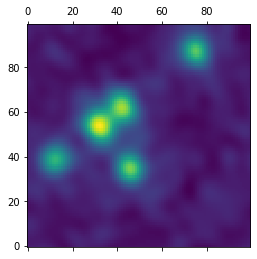

In [10]:
plt.matshow(sim_image_noisy_set[2], origin='lower')
plt.show()

In [11]:
#np.save("sim_image_noisy_set.npy", sim_image_noisy_set)